In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('ushape.csv')

In [8]:
df.head()

,X,Y,class
0,1.5824,-0.1950,1.0
1,-0.3979,-0.4888,1.0
2,0.8510,-0.4404,1.0
3,0.8420,0.7722,0.0
4,1.4144,-0.5498,1.0


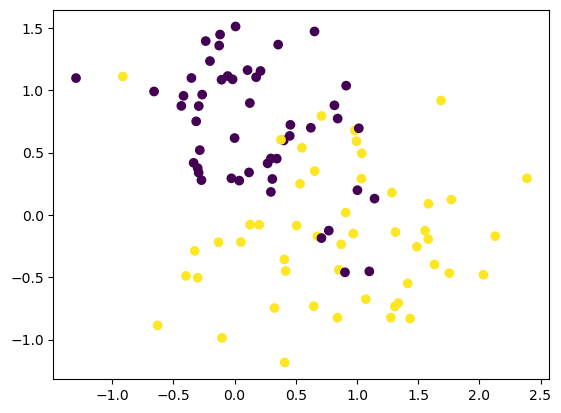

In [9]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [10]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [11]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\avraj\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Set parameters to 0
model.get_weights()

[array([[-0.68932736, -0.25281414, -0.40914693, -0.42324707, -0.12089622,
         -0.40536603,  0.60946935, -0.6023376 ,  0.48134857,  0.33454615],
        [-0.03701776,  0.6081175 ,  0.163387  ,  0.38110465,  0.45684355,
          0.00507766, -0.6015817 , -0.63929284,  0.25228494, -0.68209547]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.5830497 ],
        [ 0.06774276],
        [ 0.7187843 ],
        [-0.29437935],
        [-0.5953664 ],
        [-0.25904372],
        [ 0.41884965],
        [ 0.42140812],
        [ 0.20808595],
        [ 0.14203745]], dtype=float32),
 array([0.], dtype=float32)]

In [14]:
initial_weights = model.get_weights()

In [15]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [16]:
model.set_weights(initial_weights)

In [17]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5375 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.6946
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.6964
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5375 - loss: 0.6924 - val_accuracy: 0.3500 - val_loss: 0.6973
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6921 - val_accuracy: 0.3500 - val_loss: 0.6981
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6923 - val_accuracy: 0.3500 - val_loss: 0.6992
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6918 - val_accuracy: 0.3500 - val_loss: 0.6996
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5375 - loss: 0.6916 - val_accuracy: 0.3500 - val_loss: 0.7001
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5375 - loss: 0.6915 - val_accuracy: 0.3500 - val_loss:

In [20]:
model.get_weights()

[array([[-0.40074447, -0.40074447, -0.40074447, -0.40074447, -0.40074447,
         -0.40074447, -0.40074447, -0.40074447, -0.40074447, -0.40074447],
        [ 0.41685838,  0.41685838,  0.41685838,  0.41685838,  0.41685838,
          0.41685838,  0.41685838,  0.41685838,  0.41685838,  0.41685838]],
       dtype=float32),
 array([-0.07064134, -0.07064134, -0.07064134, -0.07064134, -0.07064134,
        -0.07064134, -0.07064134, -0.07064134, -0.07064134, -0.07064134],
       dtype=float32),
 array([[-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343],
        [-0.07818343]], dtype=float32),
 array([0.03896673], dtype=float32)]

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary_with_line(model, X, y, title="Zero Init - Sigmoid"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                          np.arange(y_min, y_max, 0.01))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid, verbose=0).reshape(xx.shape)

    # shaded background regions
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#7fb3d5', '#f5cba7'], alpha=0.5)

    # THE SEPARATING LINE — explicit boundary at probability = 0.5
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40)
    plt.xlabel('X'); plt.ylabel('Y')
    plt.title(title)
    plt.show()

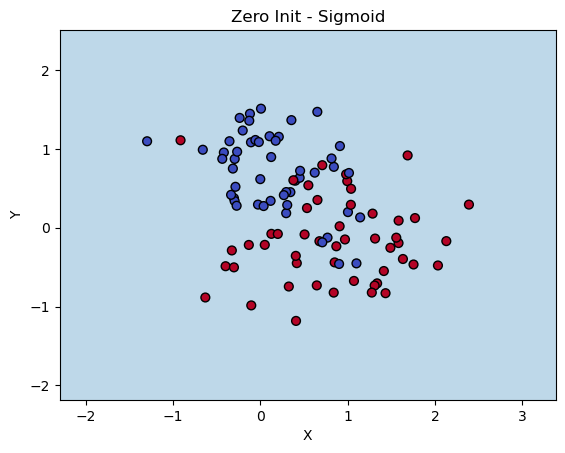

In [24]:
# in zero-initialization-sigmoid.ipynb
plot_decision_boundary_with_line(model, X, y, title="Zero Init - Sigmoid")